# Sentiment Analysis Using Bag of Words and Artificial Neural Network (ANN)

## Project Overview

Natural Language Processing (NLP) enables machines to understand, analyze, and extract meaningful information from human language. One of the most fundamental NLP tasks is **Sentiment Analysis**, which aims to determine whether a piece of text expresses a positive or negative opinion.

In this project, I build a complete sentiment analysis pipeline using classical NLP techniques and Machine Learning algorithms. The workflow covers the entire process from raw text preprocessing to feature extraction, model training, evaluation, and experiment documentation.

The primary objective of this project is not only to achieve high predictive performance but also to systematically investigate how different preprocessing techniques, feature engineering strategies, and machine learning models affect sentiment classification performance.

---

## Dataset

Dataset Link: **[IMBD Movie Reviews](https://www.kaggle.com/datasets/mwallerphunware/imbd-movie-reviews-for-binary-sentiment-analysis)**

The dataset consists of movie reviews labeled with their corresponding sentiment:

* Positive
* Negative

The reviews contain real-world natural language, making them suitable for evaluating text preprocessing techniques and machine learning models.

---

## Project Pipeline

The following stages are implemented throughout this project:

### 1. Text Preprocessing

* Contraction expansion
* Lowercasing
* Text cleaning using regular expressions
* Stopword removal with preserved negations
* Lemmatization
* Corpus construction

### 2. Feature Extraction

* Bag of Words (CountVectorizer)
* N-gram generation
* Vocabulary analysis
* Feature selection using `max_features`
* Rare-word filtering using `min_df`

### 3. Model Training

Different machine learning algorithms are evaluated and compared, including:

* Gaussian Naive Bayes
* Multinomial Naive Bayes
* Bernoulli Naive Bayes
* Logistic Regression
* Support Vector Machines (SVM)
* Decision Trees
* Random Forests

### 4. Model Evaluation

Performance is assessed using multiple metrics:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC Score
* Confusion Matrix
* Cross-Validation Mean Accuracy
* Cross-Validation Standard Deviation

---

## Experimental Approach

Rather than training a single model, this notebook follows an experimentation-driven methodology.

For each model, multiple configurations are tested, including different values for:

* `max_features`
* `min_df`
* N-gram ranges
* Preprocessing strategies

The goal is to identify the most effective configuration while understanding the trade-offs between model complexity, computational cost, and predictive performance.

---

## Key Learning Objectives

Through this project, I aim to:

* Develop a deeper understanding of NLP preprocessing techniques.
* Compare the behavior of different machine learning algorithms on text data.
* Analyze how feature engineering impacts classification performance.
* Build reproducible NLP pipelines suitable for real-world applications.
* Establish strong baselines before moving toward advanced embedding and transformer-based approaches.

---

**Author:** Hazem Mohamed

**Role:** AI Engineer | Machine Learning Engineer | NLP Engineer

**Repository:** [NLP Experimentation Lab](https://github.com/Hazem1695/NLP-Experimentation-Lab)


# **Importing the Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

In [2]:
tf.__version__

'2.20.0'

# **Data preprocessing**

## Data Cleaning Check Template
This template is designed to quickly assess the quality of any dataset before building machine learning models or performing analysis.

It provides a structured overview of the dataset by checking for common data issues such as:

- Missing values

- Duplicate rows

- Incorrect data types

- Outliers

- Distribution of numerical features

- Categorical feature consistency

**What This Template Does**

- Displays basic dataset information (shape, data types)

- Identifies missing values and duplicates

- Summarizes numerical and categorical features

- Detects potential outliers using the IQR method

- Highlights columns with low unique values for quick inspection

How to Use

1. Load your dataset using Pandas  

2. Call the function:

In [4]:
def data_quality_report(df):

    print("DATA QUALITY REPORT")
    
    # Print a separator line for better readability
    
    print("=" * 50)
    print("BASIC INFO")
    print("=" * 50)
    
    # Show general information about the dataset (columns, data types, non-null values)
    print(df.info())
    
    # Show number of rows and columns
    print("\n" + "=" * 50)
    print("SHAPE OF DATA")
    print("=" * 50)
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    # Check for missing (null) values in each column
    print("\n" + "=" * 50)
    print("MISSING VALUES")
    print("=" * 50)
    missing = df.isnull().sum()
    
    # Display only columns that have missing values
    print(missing[missing > 0])
    
    # Check for duplicate rows
    print("\n" + "=" * 50)
    print("DUPLICATES")
    print("=" * 50)
    print(f"Duplicate rows: {df.duplicated().sum()}")
    
    # Display data types of each column
    print("\n" + "=" * 50)
    print("DATA TYPES")
    print("=" * 50)
    print(df.dtypes)
    
    # Summary statistics for numerical columns (mean, std, min, max, etc.)
    print("\n" + "=" * 50)
    print("NUMERICAL SUMMARY")
    print("=" * 50)
    print(df.describe())
    
    # Summary for categorical (object) columns
    print("\n" + "=" * 50)
    print("CATEGORICAL SUMMARY")
    print("=" * 50)
    print(df.describe(include=['object']))
    
    # Show unique values for columns with low number of distinct values
    # Useful for detecting categories, errors, or inconsistencies
    print("\n" + "=" * 50)
    print("UNIQUE VALUES (LOW CARDINALITY)")
    print("=" * 50)
    for col in df.columns:
        if df[col].nunique() < 10:  # Only show columns with few unique values
            print(f"{col}: {df[col].unique()}")
            
    # correlation
    print("\n" + "=" * 50)
    print("CORRELATION MATRIX")
    print("=" * 50)
    print(df.corr(numeric_only=True))
    
    # Detect outliers using the IQR (Interquartile Range) method
    print("\n" + "=" * 50)
    print("OUTLIERS CHECK (IQR METHOD)")
    print("=" * 50)
    
    # Loop through only numerical columns
    for col in df.select_dtypes(include=np.number).columns:
        Q1 = df[col].quantile(0.25)  # 25th percentile
        Q3 = df[col].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Interquartile range
        
        # Count rows that fall outside the normal range
        outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
        print(f"{col}: {len(outliers)} outliers")

## **Load dataset**
Apply Data Cleaning Check Template

In [ ]:
dataset = pd.read_csv('MovieReviewTrainingDatabase.csv')
data_quality_report(dataset)

DATA QUALITY REPORT
BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  25000 non-null  object
 1   review     25000 non-null  object
dtypes: object(2)
memory usage: 390.8+ KB
None

SHAPE OF DATA
Rows: 25000, Columns: 2

MISSING VALUES
Series([], dtype: int64)

DUPLICATES
Duplicate rows: 96

DATA TYPES
sentiment    object
review       object
dtype: object

NUMERICAL SUMMARY
       sentiment                                             review
count      25000                                              25000
unique         2                                              24904
top     Positive  You do realize that you've been watching the E...
freq       12500                                                  3

CATEGORICAL SUMMARY
       sentiment                                             review
count      25000                 

## Duplicate Data Detection

In [6]:
duplicates = dataset[dataset.duplicated(subset=['review'], keep=False)]
duplicates.sort_values('review')

,sentiment,review
21186,Negative,"Back in his youth, the old man had wanted to..."
21877,Negative,"Back in his youth, the old man had wanted to..."
14734,Negative,'Dead Letter Office' is a low-budget film abou...
5519,Negative,'Dead Letter Office' is a low-budget film abou...
7011,Positive,".......Playing Kaddiddlehopper, Col San Fernan..."
...,...,...
2685,Negative,"in this movie, joe pesci slams dunks a basketb..."
22244,Positive,it's amazing that so many people that i know h...
14767,Positive,it's amazing that so many people that i know h...
12462,Negative,this movie begins with an ordinary funeral... ...


## Quantifying Duplicate Review Frequencies

In [7]:
review_counts = dataset['review'].value_counts()
print("Reviews appearing more than once:")
print((review_counts > 1).sum())
print("\nMaximum repetitions:")
print(review_counts.max())

Reviews appearing more than once:
92

Maximum repetitions:
3


## Removing Duplicate Reviews & Resetting Index
> **Note:** This cell drops the repeated rows we identified in the previous steps and cleanly resets the row indices for model training

In [8]:
print("Before:", len(dataset))
dataset = dataset.drop_duplicates()
print("After:", len(dataset))
dataset = dataset.reset_index(drop=True)

Before: 25000
After: 24904


## Library Installation
> **Note:** The `contractions` library is required to automatically expand shortcuts like *don't* to *do not* and *I'm* to *I am* during preprocessing.

In [9]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00


## **Cleaning the texts**

In [10]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
import re
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

base_stopwords = set(stopwords.words('english'))
negation_words = {'not', 'no', 'never'}
all_stopwords = base_stopwords - negation_words

wnl = WordNetLemmatizer()

corpus = []

for i in range(0, len(dataset)):
    review = dataset['review'][i]
    # Fix contractions
    review = contractions.fix(review)
    # Lowercase
    review = review.lower()
    
    review = re.sub(r'[^a-zA-Z\s]', ' ', review)
    # Split
    words = review.split()
    # Chained Lemmatization (Handles both Verbs 'v' and Nouns 'n')
    review = [wnl.lemmatize(wnl.lemmatize(word, pos='v'), pos='n') for word in words if word not in all_stopwords]
    review = ' '.join(review) 
    corpus.append(review)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


## Preprocessing Verification
> **Note:** Pulling the first two rows directly as a memory array to confirm that our lowercasing, stopword stripping, and lemmatization pipeline worked correctly before feeding it into the vectorizer.

In [11]:
# Pull the data directly as a fast memory array
raw_samples = dataset['review'].head(2).values

for i in range(2):
    print(f"=== REVIEW #{i+1} ===")
    print(f"RAW:     {raw_samples[i]}\n") 
    print(f"CLEANED: {corpus[i]}")
    print("-" * 50)

=== REVIEW #1 ===
RAW:     With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.  Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.  The actual feature film bit when it final

# **Encoding Categorical data Using Label Encoding**

In [12]:
from sklearn.preprocessing import LabelEncoder
y = dataset.iloc[:, 0].values
le = LabelEncoder()
y = le.fit_transform(y)

In [13]:
print(y)

[1 1 0 ... 0 0 1]


# Class Balance Check
> **Note:** Using NumPy to verify if our dataset is perfectly balanced between positive and negative reviews before splitting it into training and testing sets.

In [14]:
# This returns the unique classes and how many times they appear
classes, counts = np.unique(y, return_counts=True)
for c, count in zip(classes, counts):
    print(f"Class {c} contains {count}")

Class 0 contains 12432
Class 1 contains 12472


# **Splitting the dataset into the Training set and Test set**

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(corpus, y, test_size = 0.20, random_state = 0)

# **Creating the Bag of Word model**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# Add ngram_range=(1, 2) so it automatically catches phrases like "not good" or "no clue"
cv = CountVectorizer(max_features=30000, min_df=2, ngram_range=(1, 2))
X_train = cv.fit_transform(X_train).toarray()
X_test = cv.transform(X_test).toarray()

In [17]:
print(X_train.shape)        # (n_samples, n_features)
print(X_train.shape[0])     # number of training samples
print(X_train.shape[1])     # number of features (vocabulary size)

(19923, 30000)
19923
30000


In [18]:
print(X_test.shape)        # (n_samples, n_features)
print(X_test.shape[0])     # number of training samples
print(X_test.shape[1])     # number of features (vocabulary size)

(4981, 30000)
4981
30000


# Building the ANN Model Architecture

In [19]:
input_dim = X_train.shape[1]
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Input(shape =(input_dim,)))
ann.add(tf.keras.layers.Dense(units=128, activation='relu')) # rectifier = relu
ann.add(tf.keras.layers.Dropout(0.4))
ann.add(tf.keras.layers.Dense(units=32, activation='relu'))
ann.add(tf.keras.layers.Dropout(0.2))
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

I0000 00:00:1785167613.512393      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785167613.515188      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Compiling the ANN Model

In [20]:
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

## Setting Up Callbacks: Early Stopping & Learning Rate Reduction

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True), ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)]

## Training the ANN Model

In [22]:
ann.fit(X_train, y_train, batch_size = 128, validation_split=0.15, epochs = 50, callbacks=callbacks)

Epoch 1/50
 13/133 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5807 - loss: 0.6619

I0000 00:00:1785167631.765446     142 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


133/133 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.8500 - loss: 0.3580 - val_accuracy: 0.8929 - val_loss: 0.2878 - learning_rate: 0.0010
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9568 - loss: 0.1281 - val_accuracy: 0.8852 - val_loss: 0.3478 - learning_rate: 0.0010
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9866 - loss: 0.0471
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9862 - loss: 0.0455 - val_accuracy: 0.8883 - val_loss: 0.4714 - learning_rate: 0.0010
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9965 - loss: 0.0167 - val_accuracy: 0.8903 - val_loss: 0.5493 - learning_rate: 5.0000e-04
Epoch 5/50
132/133 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9985 - loss: 0.0095
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9986 - loss: 0.0089 - v

# **Predicting the Test set results**

In [24]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[[1 1]
 [1 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


# **Evaluating the Model Performance**

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred))

"""
accuracies = cross_val_score(estimator=ann, X=X_train, y=y_train, cv=3)

print("\nMean Accuracy:")
print(accuracies.mean())

print("\nStandard Deviation:")
print(accuracies.std())
"""

Confusion Matrix:
[[2195  325]
 [ 172 2289]]

Accuracy Score:
0.9002208391889179

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      2520
           1       0.88      0.93      0.90      2461

    accuracy                           0.90      4981
   macro avg       0.90      0.90      0.90      4981
weighted avg       0.90      0.90      0.90      4981


ROC-AUC Score:
0.9005707287655682


'\naccuracies = cross_val_score(estimator=ann, X=X_train, y=y_train, cv=3)\n\nprint("\nMean Accuracy:")\nprint(accuracies.mean())\n\nprint("\nStandard Deviation:")\nprint(accuracies.std())\n'

# Displaying ANN Model Summary

In [26]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     3,840,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,532,869 (43.99 MB)

 Trainable params: 3,844,289 (14.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,688,580 (29.33 MB)

# Visualization

## Visualizing ANN Architecture Diagram

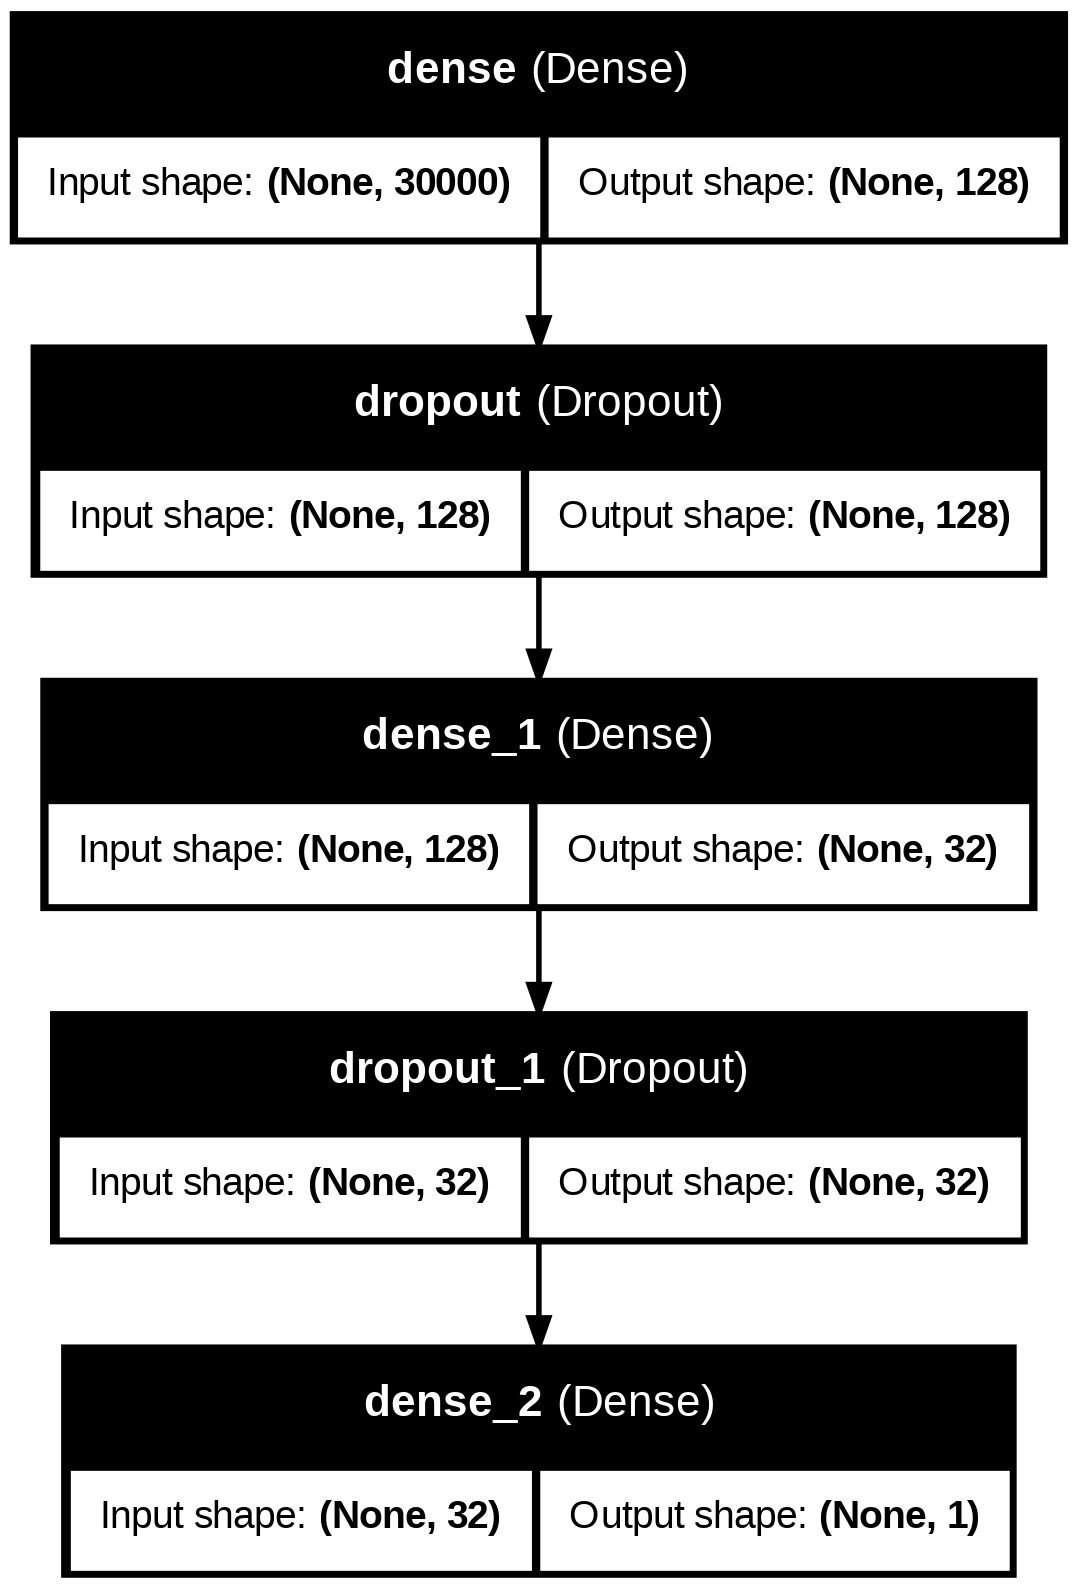

In [40]:
from tensorflow.keras.utils import plot_model

plot_model(
    ann,
    to_file="ann_model.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=200
)

## Visualizing the Confusion Matrix

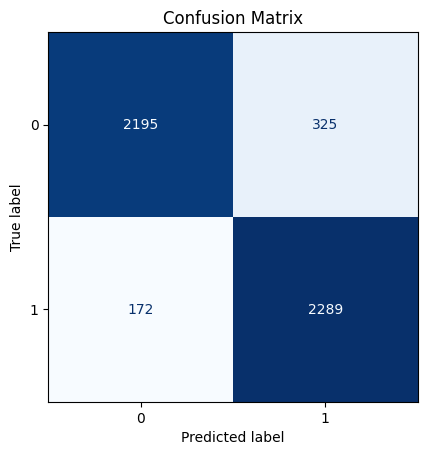

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

## Visualizing Prediction Probabilities

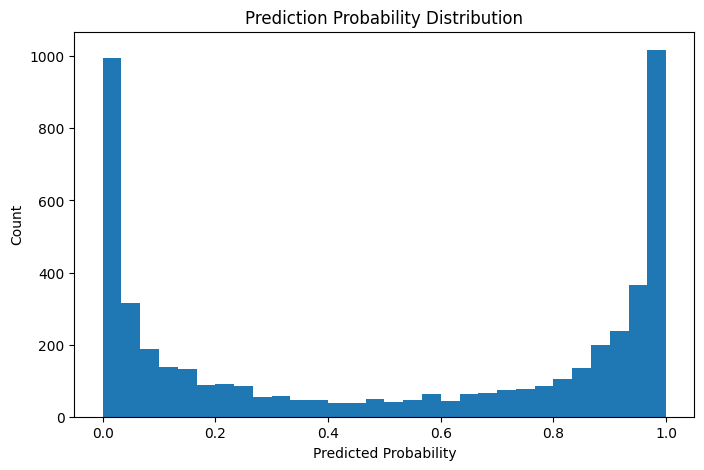

In [49]:
plt.figure(figsize=(8,5))
plt.hist(y_prob, bins=30)

plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")

plt.show()

# Artificial Neural Network (ANN) Performance Analysis for Text Classification

# 1. Objective

The objective of this experiment was to evaluate the effectiveness of a feedforward **Artificial Neural Network (ANN)** for binary text classification using features generated by **CountVectorizer**, and to compare its performance against the previously evaluated Decision Tree, Random Forest, and XGBoost classifiers.

Unlike the previous experiments, this one varies the model's *architecture* itself (depth, width, dropout, training procedure) alongside vocabulary size, rather than tuning hyperparameters of a fixed model type. This makes it structurally different enough from the earlier reports to warrant a few additional sections.

The experiment aims to answer the following research questions:

* How does a simple feedforward ANN compare to tree-based models on the same features?
* Does the same "vocabulary size" pattern seen in Decision Tree, Random Forest, and XGBoost (peak around 10K, decline after) hold for a neural network?
* How much of the improvement across runs is attributable to vocabulary size vs. architecture vs. regularization/training changes?
* What is the computational/parameter cost of scaling vocabulary size for a dense input layer, compared to the essentially free scaling of tree-based models?

---

# 2. Experimental Setup

## Dataset

* Final test set: **4,981 documents** (2,520 negative / 2,461 positive).

## Feature Extraction

| Run | Vectorizer Configuration |
| --- | ------------------------- |
| 1   | `CountVectorizer()` (default, no max_features limit) |
| 2   | max_features=5000, ngram_range=(1,2) |
| 3   | max_features=5000, ngram_range=(1,2) |
| 4   | max_features=10000, ngram_range=(1,2) |
| 5   | max_features=15000, ngram_range=(1,2) |
| 6   | max_features=20000, min_df=2, ngram_range=(1,2) |
| 7   | max_features=30000, min_df=2, ngram_range=(1,2) |

> No k-fold cross-validation was performed for any run in this experiment — see Section 10.

---

# 3. Model Architectures Explored

Two distinct architecture families were used across the seven runs:

**Family A — Minimal network (Runs 1-2)**
```python
Dense(units=6, activation='relu')
Dense(units=6, activation='relu')
Dense(units=1, activation='sigmoid')
```
No dropout, no explicit `Input` layer.

**Family B — Regularized network (Runs 3-7)**

Run 3 used a smaller version:
```python
Input(shape=(input_dim,))
Dense(units=64, activation='relu')
Dropout(0.3)
Dense(units=16, activation='relu')
Dropout(0.2)
Dense(units=1, activation='sigmoid')
```

Runs 4-7 scaled this up and standardized on:
```python
Input(shape=(input_dim,))
Dense(units=128, activation='relu')
Dropout(0.4)
Dense(units=32, activation='relu')
Dropout(0.2)
Dense(units=1, activation='sigmoid')
```

Runs 4-7 share an identical architecture — only the vectorizer's vocabulary size changed between them, which makes this the one clean, isolated comparison in the experiment (see Section 6).

---

# 4. Training Configuration

| Run | Batch Size | Epochs (requested) | Callbacks | Notes |
| --- | ---------- | -------------------- | --------- | ----- |
| 1   | 32         | 100                  | None      | Trained full 100 epochs, no validation monitoring |
| 2   | 32         | 100                  | None      | Same as Run 1 |
| 3   | 64         | 30                  | None | Trained full 30 epochs, no validation monitorin |
| 4   | 128        | 50 (requested)        | EarlyStopping(patience=4, restore_best_weights=True), ReduceLROnPlateau(factor=0.5, patience=2) | Log comment notes training stopped around epoch 5 |
| 5   | 128        | 50 (requested)        | Same as Run 4 | Same architecture/training as Run 4 |
| 6   | 128        | 50 (requested)        | Same as Run 4 | Same architecture/training as Run 4 |
| 7   | 128        | 50 (requested)        | Same as Run 4 | Same architecture/training as Run 4 |

> ⚠️ **Confound flag:** Runs 1-2 (no dropout, no early stopping, full 100-epoch training) are not directly comparable to Runs 3-7 (dropout + early stopping, effectively ~5 epochs) — vocabulary size, architecture, *and* training regime all changed together. Runs 4-7 are the one genuinely apples-to-apples comparison, since architecture and training procedure are held constant and only vocabulary size varies.

---

# 5. Experimental Results

| Run | Configuration | Accuracy | ROC-AUC |
| --- | -------------- | -------- | ------- |
| 1   | Default vocab, [6,6,1] net, 100 epochs, no dropout | 86.15%  | 0.8618 |
| 2   | 5K features, [6,6,1] net, 100 epochs, no dropout   | 83.00%  | 0.8301 |
| 3   | 5K features, [64,16,1] net, dropout                 | 86.65%  | 0.8668 |
| 4   | 10K features, [128,32,1] net, dropout + early stop  | 88.92%  | 0.8896 |
| 5   | 15K features, [128,32,1] net, dropout + early stop  | 89.08%  | 0.8909 |
| 6   | 20K features (min_df=2), [128,32,1] net, dropout + early stop | 89.32%  | 0.8934 |
| 7   | **30K features (min_df=2), [128,32,1] net, dropout + early stop** | **90.02%** | **0.9006** |

---

# 6. Performance Analysis

## Effect of Architecture Upgrade (Isolated Comparison: Run 2 vs. Run 3)

Runs 2 and 3 use the **same vectorizer configuration** (5K features, bigrams), so this is a clean comparison of architecture alone:

| Run | Architecture | Accuracy |
| --- | ------------- | -------- |
| 2   | [6, 6, 1], no dropout | 83.00% |
| 3   | [64, 16, 1], dropout   | 86.65% |

Upgrading from a minimal 2×6-unit network to a deeper, wider, regularized network improved accuracy by **3.65 points** at the same vocabulary size — architecture capacity, not vocabulary, drove this gain.

## Effect of Vocabulary Size (Isolated Comparison: Runs 4-7, Same Architecture)

This is the cleanest ablation in the experiment, since architecture and training procedure are held fixed:

| Run | Features | Accuracy   |
| --- | -------- | ---------- |
| 4   | 10K      | 88.92%     |
| 5   | 15K      | 89.08%     |
| 6   | 20K      | 89.32%     |
| 7   | **30K**  | **90.02%** |

**This directly contradicts the pattern seen in every prior CountVectorizer experiment.** Decision Tree, Random Forest, and XGBoost all peaked around 10K features and slightly declined at 15K. Here, accuracy climbs *monotonically* all the way to 30K, with no sign of plateauing yet. A plausible explanation is that dropout (0.4 / 0.2) gives the network enough regularization to keep exploiting additional vocabulary without overfitting, whereas the tree-based models' capacity constraints (depth, leaf minimums) capped how much extra vocabulary they could productively use. This is a genuinely useful cross-model finding worth carrying into the combined report.

## Effect of Default vs. Restricted Vocabulary (Run 1 vs. Run 2, Same Tiny Architecture)

Run 1 (default `CountVectorizer()`, unigrams only, full vocabulary) outperformed Run 2 (5K features, bigrams) by over 3 points (86.15% vs. 83.00%) despite Run 2 nominally having "more informative" bigram features. With such a small network (6-6-1), the additional bigram dimensions in Run 2 likely added more noise than the minimal network could productively use, while Run 1's larger but simpler unigram vocabulary was easier for a tiny network to exploit.

## Training Dynamics: Early Stopping

For Runs 4-7, the log notes training halted around epoch 5 of a requested 50 — `EarlyStopping` triggered quickly, suggesting validation loss stopped improving almost immediately. This means the strong 10K-30K results were achieved with very little actual training time, which is worth keeping in mind if you revisit these models: there may be headroom left if `patience` were increased or the learning-rate schedule adjusted, though it's equally possible the model was already at its practical ceiling for this feature representation.

---

# 7. Precision and Recall Analysis

| Run | Class | Precision | Recall | F1-score |
| --- | ----- | --------- | ------ | -------- |
| 1   | 0     | 0.89      | 0.83   | 0.86     |
| 1   | 1     | 0.84      | 0.89   | 0.86     |
| 2   | 0     | 0.84      | 0.82   | 0.83     |
| 2   | 1     | 0.82      | 0.84   | 0.83     |
| 3   | 0     | 0.89      | 0.84   | 0.86     |
| 3   | 1     | 0.85      | 0.89   | 0.87     |
| 4   | 0     | 0.92      | 0.85   | 0.89     |
| 4   | 1     | 0.86      | 0.93   | 0.89     |
| 5   | 0     | 0.90      | 0.88   | 0.89     |
| 5   | 1     | 0.88      | 0.90   | 0.89     |
| 6   | 0     | 0.91      | 0.88   | 0.89     |
| 6   | 1     | 0.88      | 0.91   | 0.89     |
| **7** | **0** | **0.93**  | **0.87** | **0.90** |
| **7** | **1** | **0.88**  | **0.93** | **0.90** |

A consistent pattern across Runs 4-7: precision is higher on Class 0, recall is higher on Class 1 — the network is more conservative about calling something Class 0 but more liberal (and accurate) about catching Class 1. This asymmetry is present but comparatively mild in Run 5-6, and re-widens slightly in the best model (Run 7).

---

# 8. ROC-AUC Analysis

| Run | Configuration | ROC-AUC |
| --- | -------------- | ------- |
| 1   | Default vocab, minimal net | 0.8618 |
| 2   | 5K, minimal net             | 0.8301 |
| 3   | 5K, regularized net         | 0.8668 |
| 4   | 10K, regularized net        | 0.8896 |
| 5   | 15K, regularized net        | 0.8909 |
| 6   | 20K, regularized net        | 0.8934 |
| **7** | **30K, regularized net**  | **0.9006** |

ROC-AUC tracks accuracy closely throughout, and Run 7 is the first result in the entire CountVectorizer series (across all four model types tested) to cross **0.90**.

---

# 9. Model Complexity Analysis

| Run | Vocab Size | Trainable Params    | Total Params (incl. optimizer state)    |
| --- | ---------- | ------------------- | --------------------------------------- |
| 3   | 5,000      | 321,121             | 963,365                                 |
| 4   | 10,000     | 1,284,289           | 3,852,869                               |
| 5   | 15,000     | 1,924,289           | 5,772,869                               |
| 6   | 20,000     | 2,564,289           | 7,692,869                               |
| 7   | 30,000     | 3,844,289           | 11,532,869                              |

Because the first dense layer connects directly to every input dimension, trainable parameters scale almost linearly with vocabulary size (roughly `vocab_size × 128` for the first layer alone). Note the consistent relationship in every row where data is available: **Total params ≈ 3 × Trainable params** — Adam's optimizer state (first and second moment estimates) doubles the trainable count, plus a couple of scalar tracking variables. The best-performing model (Run 7, 30K features) is estimated at roughly **3.8M trainable parameters** — a meaningfully heavier model than any tree-based classifier in this series, worth factoring in if training time or deployment size matters.

---

# 10. Cross-Validation

**No k-fold cross-validation was performed for any run in this experiment.** All prior CountVectorizer reports (Decision Tree, Random Forest, XGBoost) included a `cross_val_score`-based CV mean/std; this ANN experiment relied instead on a single train/test split, with `validation_split=0.15` used internally for early stopping in Runs 4-7. This means the accuracy figures here don't have the same stability signal (CV std) that the other reports do, and are somewhat more likely to reflect a single lucky or unlucky split. If reproducible CV is wanted for the combined report, it would need a `KerasClassifier` wrapper (via `scikeras`) around the model to run through `cross_val_score`, which is significantly more expensive for a neural network than for the sklearn models.

---

# 11. Best Model Configuration

```python
CountVectorizer(
    max_features=30000,
    min_df=2,
    ngram_range=(1, 2)
)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=1, activation='sigmoid'),
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
]
model.fit(X_train, y_train, batch_size=128, validation_split=0.15, epochs=50, callbacks=callbacks)
```

Performance:

* Accuracy = **90.02%**
* Precision (Class 0 / 1) = **0.93 / 0.88**
* Recall (Class 0 / 1) = **0.87 / 0.93**
* ROC-AUC = **0.9006**
* Cross-Validation: not performed (see Section 10)

---

# 12. Comparison with Previously Evaluated Models (CountVectorizer)

| Model                | Best Accuracy | ROC-AUC    |
| ---------------------- | -------------- | ---------- |
| **ANN**                 | **90.02%**     | **0.9006** |
| XGBoost                 | 87.45%         | 0.8747     |
| Random Forest           | 86.13%         | 0.8614     |
| Logistic Regression     | *fill in*      | *fill in*  |
| LinearSVC               | *fill in*      | *fill in*  |
| Naive Bayes             | *fill in*      | *fill in*  |
| K-Nearest Neighbors     | *fill in*      | *fill in*  |
| Decision Tree           | 74.34%         | 0.7441     |

The ANN is the strongest CountVectorizer result of the entire series so far, ahead of XGBoost by 2.6 points and Random Forest by nearly 4 points

---

# 13. Discussion

Two separate findings deserve equal weight in this experiment.

First, on raw performance: the regularized ANN architecture (Runs 4-7) is the best-performing model of the entire CountVectorizer series, and — unlike Decision Tree, Random Forest, and XGBoost — its accuracy kept climbing through 30K features with no sign of plateauing. This suggests the ceiling for this feature representation hasn't been found yet for neural models the way it apparently has for tree-based ones; a natural follow-up would be testing 40K+ features or a wider/deeper network to see where the curve actually bends.

Second, on methodology: this experiment mixed several variables across runs (vocabulary size, architecture depth/width, dropout, training duration) in a way the earlier, single-variable hyperparameter searches didn't. The one clean, single-variable comparison (Runs 4-7, architecture held constant) is trustworthy and is what Section 12's headline number is built on. But Runs 1-3 shouldn't be read as a controlled vocabulary-size ablation — the architecture and training procedure changed at the same time, so their differences can't be cleanly attributed to any one cause. For future architecture experiments, holding the network fixed while only sweeping the vectorizer (as Runs 4-7 did) gives much more interpretable results than changing both at once.

---

# 14. Final Conclusion

This experiment evaluated a feedforward ANN across two architecture families and seven vectorizer configurations. The best model used **CountVectorizer with 30,000 features, bigrams, and min_df=2**, paired with a **128→32→1 dense network with dropout (0.4/0.2), Adam optimizer, early stopping, and learning-rate reduction on plateau**, achieving **90.02% accuracy** and **0.9006 ROC-AUC** — the best result of any classifier evaluated on CountVectorizer features in this series, ahead of XGBoost (87.45%), Random Forest (86.13%), and Decision Tree (74.34%).

Unlike every tree-based model tested so far, accuracy did not plateau by 10K-15K features — it kept improving through 30K, suggesting the ANN may have more headroom left untested.